# Training Patch Classifiers from Per-Class Patch Folders

Click to open in: [[GitHub](https://github.com/TissueImageAnalytics/tiatoolbox/blob/develop/examples/13-training-patch-folder-classification.ipynb)][[Colab](https://colab.research.google.com/github/TissueImageAnalytics/tiatoolbox/blob/develop/examples/13-training-patch-folder-classification.ipynb)]


## About this notebook

This Jupyter notebook can run on a local Python environment or on Google Colab. If you run it on Colab, use the installation cell below and restart the runtime once installation finishes.


## About this demo

This example demonstrates model training for **case 1** in the training roadmap: per-class patch folders where each subfolder name defines the target class.

You will:

1. Download the small Kather 100K patch subset used in `05-patch-prediction.ipynb`.
1. Build a `PatchFolderClassificationDataset` from the folder structure.
1. Split the dataset and build loaders with TIAToolbox training helpers.
1. Train a `CNNModel` with a `resnet18` backbone using `Trainer` and `ClassificationTask`.
1. Inspect generated checkpoints and resume training from `last.ckpt`.


## Optional: Colab setup

Skip this section when running in an environment where `tiatoolbox` is already installed.


In [ ]:
%%bash
apt-get -y install libopenjp2-7-dev libopenjp2-tools openslide-tools libpixman-1-dev | tail -n 1
pip install git+https://github.com/TissueImageAnalytics/tiatoolbox.git@develop | tail -n 1
echo "Installation is done."


If you are using Colab and ran the installation cell for the first time, restart the runtime before continuing.


## Imports and configuration


In [1]:
from __future__ import annotations

from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import torch
import zarr
from matplotlib.patches import Patch
from torch.optim.lr_scheduler import CosineAnnealingLR

from tiatoolbox.models.architecture.vanilla import CNNModel
from tiatoolbox.models.dataset import predefined_preproc_func
from tiatoolbox.models.engine.io_config import IOPatchPredictorConfig
from tiatoolbox.models.engine.patch_predictor import PatchPredictor
from tiatoolbox.models.training import (
    ClassificationTask,
    PatchFolderClassificationDataset,
    Trainer,
    TrainerConfig,
    TrainingArtifactManifest,
    get_classification_augmentation,
    make_dataloaders,
    split_dataset,
)
from tiatoolbox.utils.misc import download_data, imread
from tiatoolbox.wsicore.wsireader import WSIReader

plt.rcParams["figure.dpi"] = 160
plt.rcParams["figure.facecolor"] = "white"


|2026-06-02|17:46:33.732| [WARNING] /home/mark-eastwood/miniforge3/envs/comfyui/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



|2026-06-02|17:46:34.212| [INFO] Note: NumExpr detected 24 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
|2026-06-02|17:46:34.212| [INFO] NumExpr defaulting to 16 threads.


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using inference device: {device}")


Using inference device: cuda


## Use the Kather 100K patch subset

We reuse the same small Kather patch subset used in `05-patch-prediction.ipynb`. The dataset already follows the per-class folder structure expected by `PatchFolderClassificationDataset`.


In [3]:
kather_class_to_idx = {
    "BACK": 0,
    "NORM": 1,
    "DEB": 2,
    "TUM": 3,
    "ADI": 4,
    "MUC": 5,
    "MUS": 6,
    "STR": 7,
    "LYM": 8,
}
class_names = list(kather_class_to_idx)

global_save_dir = Path("tmp")
global_save_dir.mkdir(parents=True, exist_ok=True)
patches_file_name = global_save_dir / "kather100k-validation-sample.zip"
dataset_root = global_save_dir / "kather100k-validation-sample"
wsi_file_name = global_save_dir / "sample_wsi.svs"

if not patches_file_name.exists():
    download_data(
        "https://tiatoolbox.dcs.warwick.ac.uk/datasets/kather100k-validation-sample.zip",
        patches_file_name,
    )
with ZipFile(patches_file_name, "r") as zipfile:
    zipfile.extractall(path=global_save_dir)

if not wsi_file_name.exists():
    download_data(
        "https://tiatoolbox.dcs.warwick.ac.uk/sample_wsis/TCGA-3L-AA1B-01Z-00-DX1.8923A151-A690-40B7-9E5A-FCBEDFC2394F.svs",
        wsi_file_name,
    )

sample_image = imread(next((dataset_root / class_names[0]).glob("*.tif")))
patch_size = sample_image.shape[0]

print(f"Dataset path: {dataset_root.resolve()}")
print(f"WSI path: {wsi_file_name.resolve()}")
print(f"Patch size: {patch_size}px")
for class_name in class_names:
    patch_count = len(list((dataset_root / class_name).glob("*.tif")))
    print(f"{class_name}: {patch_count} patches")

Dataset path: /media/mark-eastwood/Work/tiatoolbox/examples/tmp/kather100k-validation-sample
WSI path: /media/mark-eastwood/Work/tiatoolbox/examples/tmp/sample_wsi.svs
Patch size: 224px
BACK: 211 patches
NORM: 176 patches
DEB: 230 patches
TUM: 286 patches
ADI: 208 patches
MUC: 178 patches
MUS: 270 patches
STR: 209 patches
LYM: 232 patches


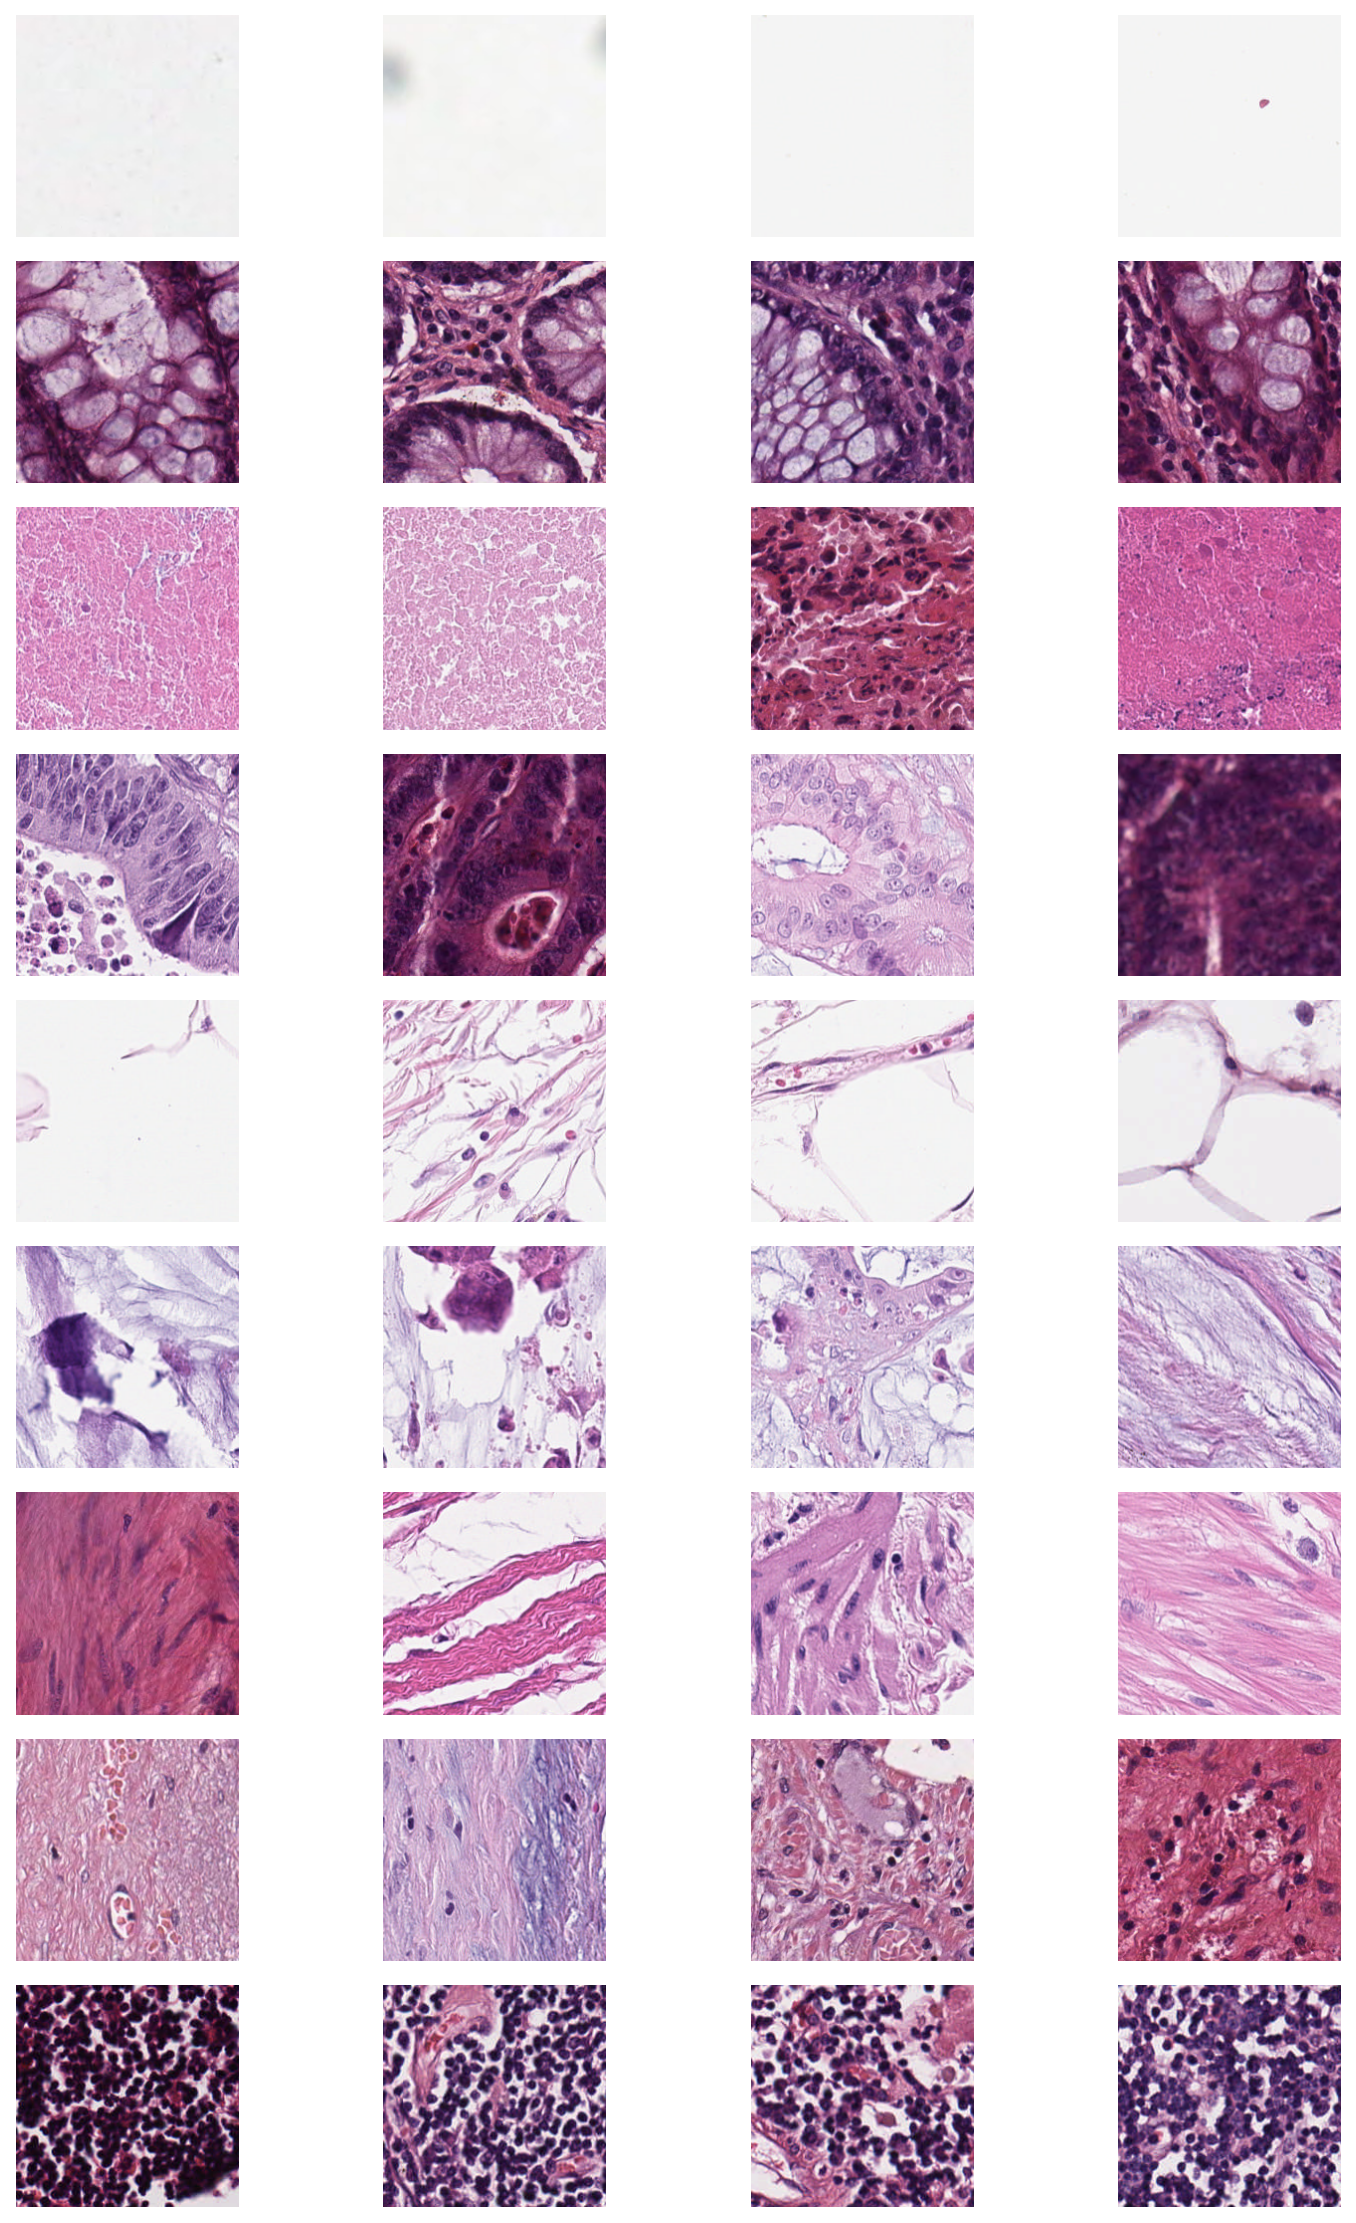

In [4]:
fig, axes = plt.subplots(len(class_names), 4, figsize=(10, 14))
for row_index, class_name in enumerate(class_names):
    sample_paths = sorted((dataset_root / class_name).glob("*.tif"))[:4]
    for col_index, sample_path in enumerate(sample_paths):
        image = imread(sample_path)
        axes[row_index, col_index].imshow(image)
        axes[row_index, col_index].axis("off")
    axes[row_index, 0].set_ylabel(class_name, rotation=90, size=10)

plt.tight_layout()

## Build dataset and dataloaders


In [5]:
augs = get_classification_augmentation(level="light")
dataset = PatchFolderClassificationDataset(
    root_dir=dataset_root,
    class_to_idx=kather_class_to_idx,
    transform=augs.transform,
)
print(f"Total patches: {len(dataset)}")
print("Class mapping:", dataset.class_to_idx)

train_dataset, val_dataset = split_dataset(
    dataset,
    val_fraction=0.2,
    stratify=True,
    seed=5,
)

print(f"Train patches: {len(train_dataset)}")
print(f"Val patches:   {len(val_dataset)}")


Total patches: 2000
Class mapping: {'BACK': 0, 'NORM': 1, 'DEB': 2, 'TUM': 3, 'ADI': 4, 'MUC': 5, 'MUS': 6, 'STR': 7, 'LYM': 8}
Train patches: 1600
Val patches:   400


In [ ]:
train_loader, val_loader = make_dataloaders(
    train_dataset,
    val_dataset,
    batch_size=16,
    num_workers=4,
)

batch = next(iter(train_loader))
print("Image batch shape:", tuple(batch["image"].shape))
print("Target batch shape:", tuple(batch["target"].shape))
print("Image dtype:", batch["image"].dtype)
print("Target dtype:", batch["target"].dtype)


Image batch shape: (16, 3, 224, 224)
Target batch shape: (16,)
Image dtype: torch.float32
Target dtype: torch.int64


## Define model and trainer

We use TIAToolbox's `CNNModel` with a vanilla `resnet18` backbone rather than defining a custom classifier inline.


In [7]:
num_classes = len(dataset.class_to_idx)


def build_model(num_output_classes, class_to_idx):
    model = CNNModel("resnet18", num_classes=num_output_classes)
    model.preproc_func = predefined_preproc_func("kather100k")
    model.class_dict = {index: name for name, index in class_to_idx.items()}
    return model


model = build_model(num_classes, dataset.class_to_idx)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

output_dir = Path("tmp/patch_folder_training_run")
output_dir.mkdir(parents=True, exist_ok=True)

wsi_ioconfig = IOPatchPredictorConfig(
    input_resolutions=[{"units": "mpp", "resolution": 0.5}],
    patch_input_shape=[patch_size, patch_size],
    stride_shape=[patch_size, patch_size],
)

training_artifact = TrainingArtifactManifest.from_model(
    model,
    task_type="classification",
    model_constructor={"architecture": "resnet18", "num_classes": num_classes},
    preprocessing={"name": "predefined_preproc_func", "preset": "kather100k"},
    postprocessing={"name": "CNNModel.postproc"},
    ioconfig=wsi_ioconfig,
    engine="PatchPredictor",
    run_kwargs={"return_probabilities": True},
    metadata={"dataset": "kather100k-validation-sample"},
)

trainer = Trainer(
    model=model,
    task=ClassificationTask(loss="cross_entropy"),
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=80,
        seed=42,
        output_dir=output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
    artifact_manifest=training_artifact,
)


## Train the model


In [ ]:
history = trainer.fit()
print(f"Finished epochs: {len(history)}")
print(f"Best epoch: {trainer.best_epoch}")
history[-1]


|2026-06-02|17:46:55.137| [INFO] Epoch 1/80 | monitor `val_loss`=1.759831 | best=1.759831
|2026-06-02|17:47:11.130| [INFO] Epoch 2/80 | monitor `val_loss`=1.587737 | best=1.587737
|2026-06-02|17:47:19.920| [INFO] Epoch 3/80 | monitor `val_loss`=1.040485 | best=1.040485
|2026-06-02|17:47:30.288| [INFO] Epoch 4/80 | monitor `val_loss`=3.267564 | best=1.040485
|2026-06-02|17:47:40.814| [INFO] Epoch 5/80 | monitor `val_loss`=1.297196 | best=1.040485
|2026-06-02|17:47:51.715| [INFO] Epoch 6/80 | monitor `val_loss`=1.854085 | best=1.040485
|2026-06-02|17:48:03.196| [INFO] Epoch 7/80 | monitor `val_loss`=1.180221 | best=1.040485
|2026-06-02|17:48:14.461| [INFO] Epoch 8/80 | monitor `val_loss`=1.518673 | best=1.040485
|2026-06-02|17:48:23.825| [INFO] Epoch 9/80 | monitor `val_loss`=1.443942 | best=1.040485
|2026-06-02|17:48:35.069| [INFO] Epoch 10/80 | monitor `val_loss`=1.251110 | best=1.040485
|2026-06-02|17:48:48.134| [INFO] Epoch 11/80 | monitor `val_loss`=3.488434 | best=1.040485
|2026-06

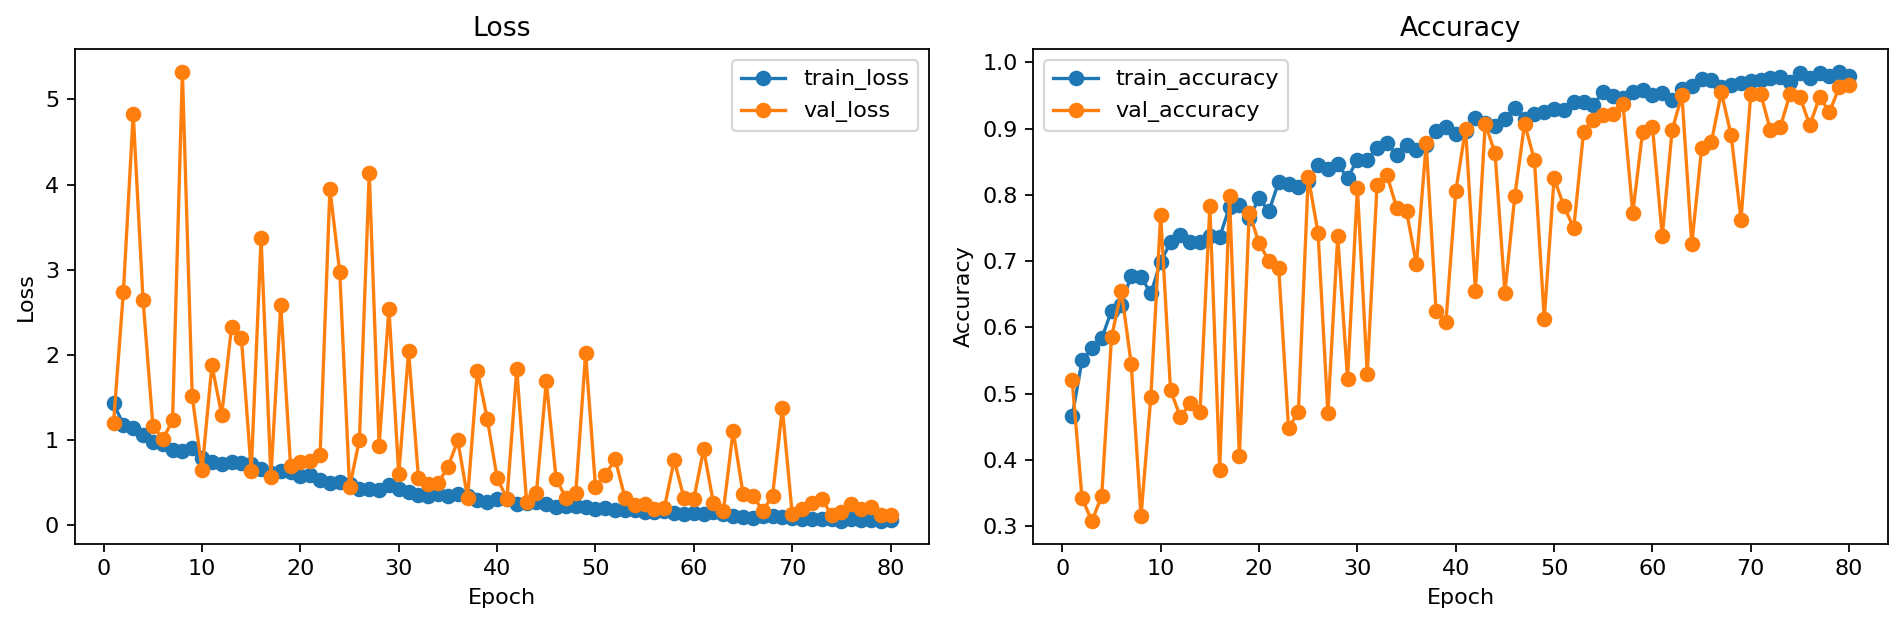

In [ ]:
epochs = [int(record["epoch"]) for record in history]
train_loss = [record["train_loss"] for record in history]
val_loss = [record.get("val_loss", np.nan) for record in history]
train_acc = [record["train_accuracy"] for record in history]
val_acc = [record.get("val_accuracy", np.nan) for record in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, marker="o", label="train_loss")
axes[0].plot(epochs, val_loss, marker="o", label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, train_acc, marker="o", label="train_accuracy")
axes[1].plot(epochs, val_acc, marker="o", label="val_accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()


## Checkpoints and resume

`Trainer` writes `last.ckpt` (full state), `best_model_weights.pth` (weights only), and `training_artifact.json` (a lightweight manifest with model hints, class labels, IO config, and relative weight paths).


In [ ]:
print("Saved checkpoint artifacts:")
for path in sorted(output_dir.glob("*")):
    print("-", path.name)

resumed_model = build_model(num_classes, dataset.class_to_idx)
resumed_optimizer = torch.optim.AdamW(
    resumed_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4,
)
resumed_scheduler = CosineAnnealingLR(
    resumed_optimizer,
    T_max=100,
    eta_min=1e-5,
)

resumed_trainer = Trainer(
    model=resumed_model,
    task=ClassificationTask(loss="cross_entropy"),
    optimizer=resumed_optimizer,
    scheduler=resumed_scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=100,
        seed=42,
        output_dir=output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
)

resumed_history = resumed_trainer.fit(resume_from=output_dir / "last.ckpt")
print(f"Resumed to epoch: {int(resumed_history[-1]['epoch'])}")


Saved checkpoint artifacts:
- best_model_weights.pth
- last.ckpt
- patchpredictor_output
- stitched_large_image.png
- training_artifact.json
|2026-05-08|03:37:02.497| [INFO] Resumed training from checkpoint `tmp/patch_folder_training_run/last.ckpt` at epoch 80.
|2026-05-08|03:37:05.904| [INFO] Epoch 81/100 | monitor `val_loss`=0.102386 | best=0.102386
|2026-05-08|03:37:09.283| [INFO] Epoch 82/100 | monitor `val_loss`=0.114704 | best=0.102386
|2026-05-08|03:37:12.849| [INFO] Epoch 83/100 | monitor `val_loss`=0.126146 | best=0.102386
|2026-05-08|03:37:17.769| [INFO] Epoch 84/100 | monitor `val_loss`=0.117666 | best=0.102386
|2026-05-08|03:37:22.694| [INFO] Epoch 85/100 | monitor `val_loss`=0.117727 | best=0.102386
|2026-05-08|03:37:29.169| [INFO] Epoch 86/100 | monitor `val_loss`=0.102348 | best=0.102348
|2026-05-08|03:37:33.031| [INFO] Epoch 87/100 | monitor `val_loss`=0.088983 | best=0.088983
|2026-05-08|03:37:37.319| [INFO] Epoch 88/100 | monitor `val_loss`=0.111745 | best=0.088983
|2

## Inference on the sample WSI with `PatchPredictor`

Instead of a synthetic stitched image, we reuse the sample WSI from `05-patch-prediction.ipynb` and run the trained `CNNModel` over it with `PatchPredictor`.


|2026-05-08|03:38:32.412| [WARNING] Read: Scale > 1.This means that the desired resolution is higher than the WSI baseline (maximum encoded resolution). Interpolation of read regions may occur.


(np.float64(-0.5), np.float64(2987.5), np.float64(2326.5), np.float64(-0.5))

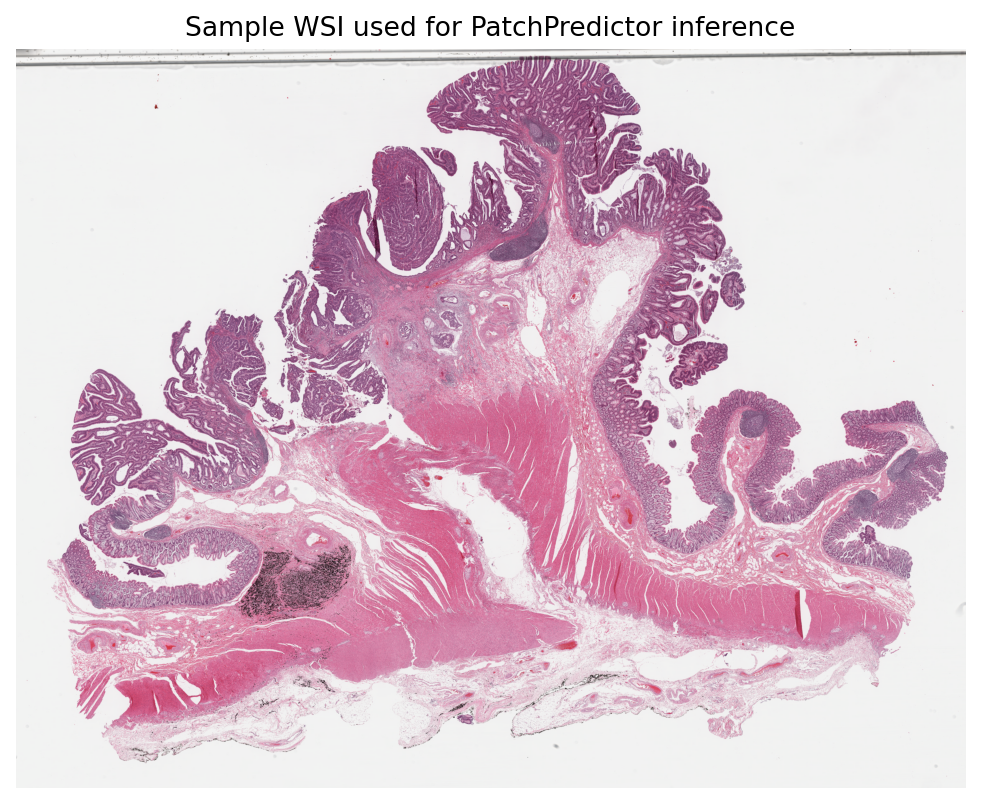

In [ ]:
wsi_reader = WSIReader.open(wsi_file_name)
wsi_thumbnail = wsi_reader.slide_thumbnail(resolution=1.25, units="power")

plt.figure(figsize=(10, 6))
plt.imshow(wsi_thumbnail)
plt.title("Sample WSI used for PatchPredictor inference")
plt.axis("off")

In [ ]:
artifact_path = output_dir / "training_artifact.json"
artifact = TrainingArtifactManifest.load(artifact_path)

inference_model = build_model(num_classes, dataset.class_to_idx)
artifact.load_weights(inference_model, manifest_path=artifact_path)
engine_setup = artifact.to_engine_setup(
    "PatchPredictor",
    manifest_path=artifact_path,
    include_weights=False,
)

predictor = PatchPredictor(
    model=inference_model,
    batch_size=32,
    num_workers=0,
    device=device,
    verbose=False,
)

predictor_output_dir = output_dir / "patchpredictor_output"

predictor_output = predictor.run(
    images=[wsi_file_name],
    masks=None,
    patch_mode=False,
    output_type="zarr",
    save_dir=predictor_output_dir,
    overwrite=True,
    **engine_setup.run_kwargs,
)

zarr_output_path = predictor_output[wsi_file_name]
print(f"PatchPredictor output: {zarr_output_path}")


|2026-05-08|03:38:33.042| [WARNING] GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.


|2026-05-08|03:38:33.043| [INFO] When providing multiple whole slide images, the outputs will be saved and the locations of outputs will be returned to the calling function when `run()` finishes successfully.


|2026-05-08|03:38:33.047| [WARNING] Read: Scale > 1.This means that the desired resolution is higher than the WSI baseline (maximum encoded resolution). Interpolation of read regions may occur.


|2026-05-08|03:40:06.094| [INFO] Output file saved at tmp/patch_folder_training_run/patchpredictor_output/sample_wsi.zarr.
PatchPredictor output: tmp/patch_folder_training_run/patchpredictor_output/sample_wsi.zarr


Predicted patch counts by class:
- BACK: 2817
- NORM: 855
- DEB: 4167
- TUM: 4808
- ADI: 1215
- MUC: 258
- MUS: 3189
- STR: 2021
- LYM: 798


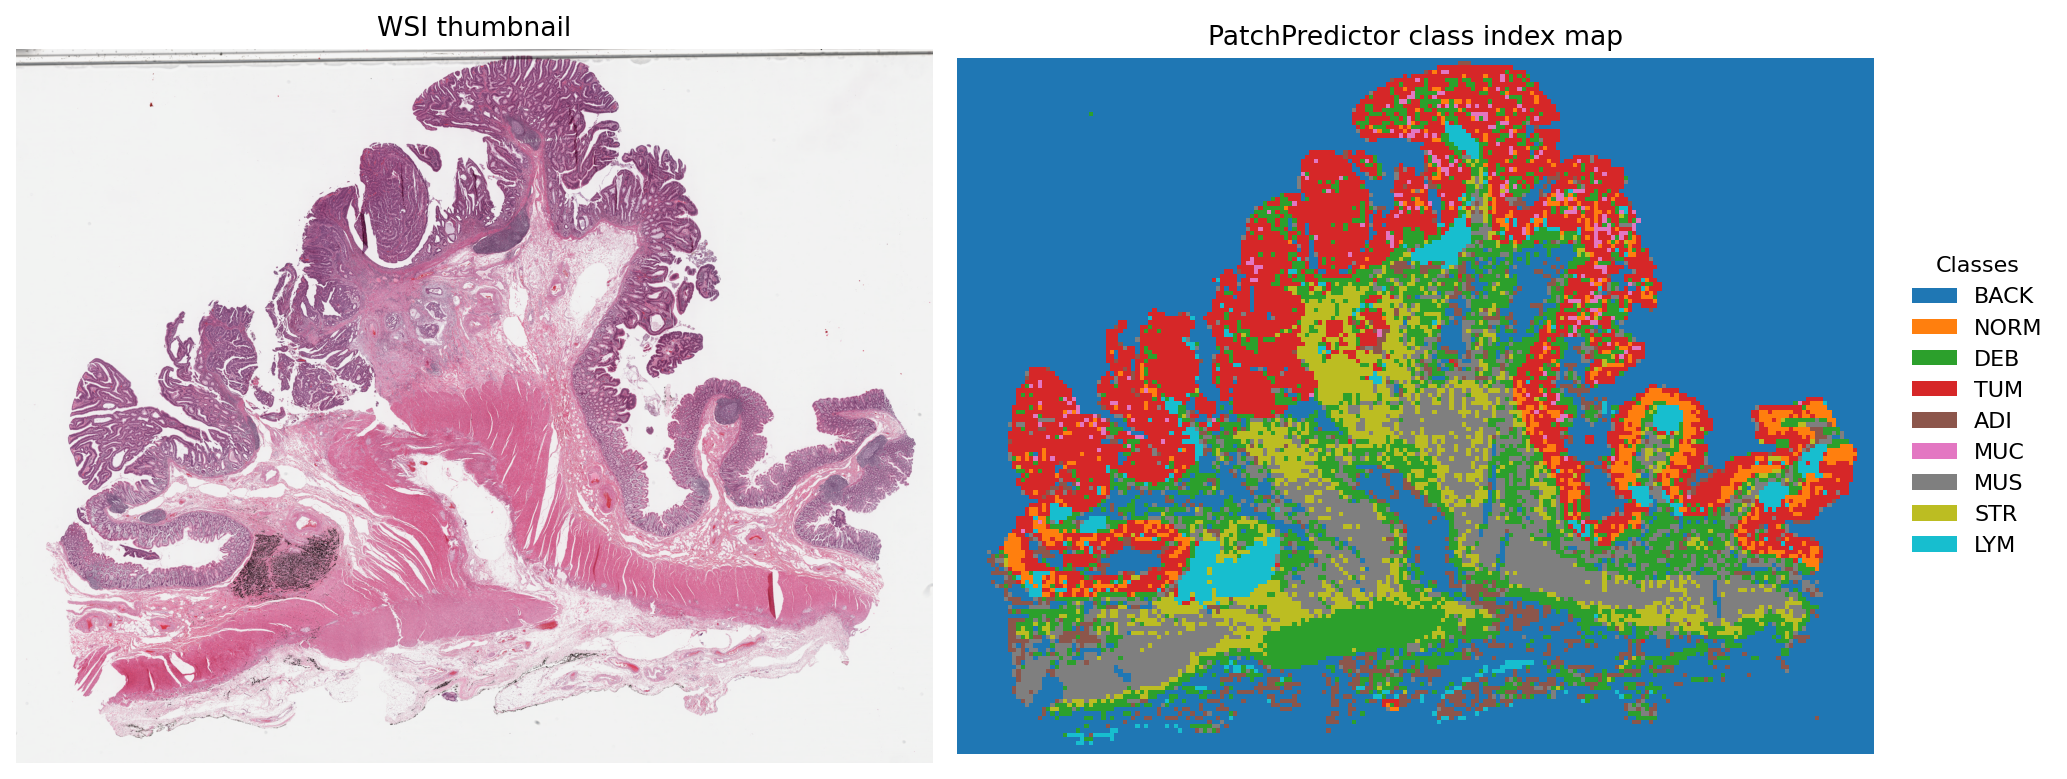

In [ ]:
zarr_output = zarr.open(zarr_output_path, mode="r")
predictions = np.array(zarr_output["predictions"])
coordinates = np.array(zarr_output["coordinates"])

x_coords = np.unique(coordinates[:, 0]).astype(int)
y_coords = np.unique(coordinates[:, 1]).astype(int)
predicted_index_map = np.full((len(y_coords), len(x_coords)), fill_value=-1, dtype=np.int64)

x_to_col = {coord: idx for idx, coord in enumerate(x_coords)}
y_to_row = {coord: idx for idx, coord in enumerate(y_coords)}
for pred_idx, (x0, y0, _, _) in zip(predictions, coordinates):
    predicted_index_map[y_to_row[int(y0)], x_to_col[int(x0)]] = int(pred_idx)

index_to_class = {index: name for name, index in dataset.class_to_idx.items()}
unique_predictions, counts = np.unique(
    predicted_index_map[predicted_index_map >= 0],
    return_counts=True,
)
print("Predicted patch counts by class:")
for class_index, count in zip(unique_predictions, counts):
    print(f"- {index_to_class[int(class_index)]}: {int(count)}")

cmap = plt.get_cmap("tab10", num_classes)
legend_handles = [
    Patch(facecolor=cmap(class_index), edgecolor="none", label=index_to_class[class_index])
    for class_index in range(num_classes)
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(wsi_thumbnail)
axes[0].set_title("WSI thumbnail")
axes[0].axis("off")

axes[1].imshow(predicted_index_map, cmap=cmap, vmin=0, vmax=num_classes - 1)
axes[1].set_title("PatchPredictor class index map")
axes[1].axis("off")
axes[1].legend(
    handles=legend_handles,
    title="Classes",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

plt.tight_layout()

## Adapting this notebook to real data

Replace `dataset_root` with your own patch directory:

```text
my_patch_dataset/
  class_a/
    patch_0001.png
    patch_0002.png
  class_b/
    patch_0003.png
```

If you want a stable label order, pass your own `class_to_idx` mapping into `PatchFolderClassificationDataset`, then keep the same dataloaders, `CNNModel`, and `Trainer` workflow.
